# Example Workflow: Lopez-Acosta et al. (2019) preprocessing

This notebook demonstrates use of the IceFloeTracker.jl package to reproduce the preprocessing steps from the original Ice Floe Tracker algorithm paper, [Lopez-Acosta et al. (2019)](https://www.sciencedirect.com/science/article/pii/S0034425719304250). The process is based on a set of 3 images acquired from the MODIS imager, downloaded from the NASA Earth Observing System [Worldview Snapshots application](https://wvs.earthdata.nasa.gov). We used the Aqua Truecolor and Aqua 7-2-1 false color layers. For the landmask, we used the Open Street Maps layer from the Worldview Snapshots [interactive web application](https://worldview.earthdata.nasa.gov/).

## Setting up your environment
In this example, we use the home folder of the IceFloeTracker.jl folder. This is appropriate for if you have cloned the GitHub repository and are running the notebook from within the folder. If you are working in a different directory, then you can define an environment using
```Pkg.activate(my_env_name)```
where `my_env_name` is whatever name you would like the environment to have. You may need to add packages individually the first time that you run the notebook.

In [4]:
HOME = "../.."

# Activate the environment
using Pkg
Pkg.activate(HOME)
Pkg.precompile()

# Load packages
using IceFloeTracker
using IceFloeTracker: load
using Images

  Activating project at `~/Documents/research/packages/IceFloeTracker.jl`


## Viewing the example images
Load the example images from the notebooks/example_images folder, then use mosaicview for a quicklook. In the mosaicview output, we see from left to right the true color, false color, and land mask images.

In [110]:
tc_image = load(joinpath(HOME, "notebooks/example_images/aqua_truecolor_snapshot-2025-04-04.tif"))
fc_image = load(joinpath(HOME, "notebooks/example_images/aqua_falsecolor_snapshot-2025-04-04.tif"))
lm_image = load(joinpath(HOME, "notebooks/example_images/osm_landmask_snapshot.tif"));

In [123]:
# Casting to RGB happens in the IFT pipeline currently.
# Our "load" function should be able to take input images and place 
# them into the format that the rest of the code uses.
tc_image = IceFloeTracker.float64.(RGB.(tc_image))
fc_image = IceFloeTracker.float64.(RGB.(fc_image))
lm_image = IceFloeTracker.float64.(RGB.(lm_image));

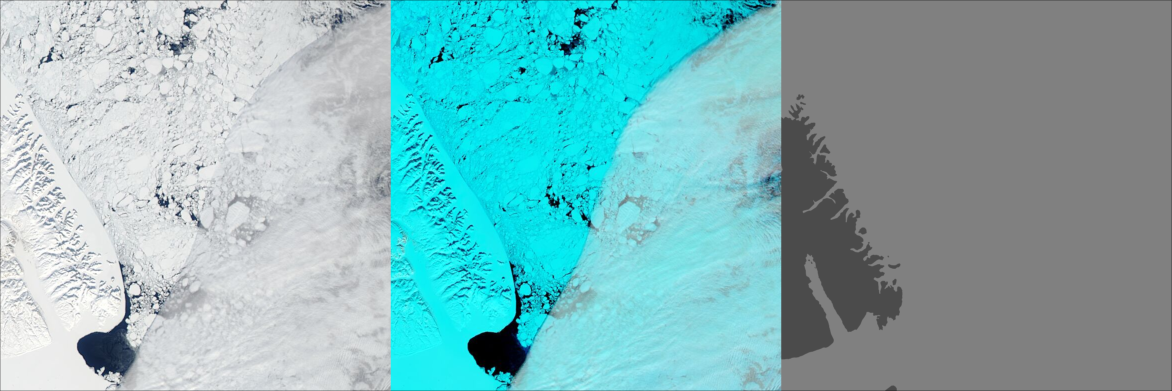

In [124]:
Images.mosaicview([tc_image, fc_image, lm_image], nrow=1)

## Generating a landmask
This image includes a portion of coastline with a complex series of fjords and islands. Landmasks can be derived from a variety of sources. Here, we've downloaded a rendering of an Open Street Map land mask. In this case, the landmask image takes two colors, both between 0 and 1. We cast the image into Bool first with 0 for land and 1 for ocean. The second argument to create_landmask is optional and can be a structuring element for dilating the land mask. We show an example below using the diamond-shaped element from ImageMorphology, then re-make the landmasks with the default disk-shaped element.

In [115]:
Float64(maximum(Gray.(lm_image)))

0.5019607843137255

In [116]:
Float64(minimum(Gray.(lm_image)))

0.29411764705882354

In [161]:
lm = Gray.(lm_image) .< 0.3
landmask_imgs = create_landmask(lm, collect(strel_diamond((25, 25))))

(dilated = Bool[1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1], non_dilated = Bool[1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1])

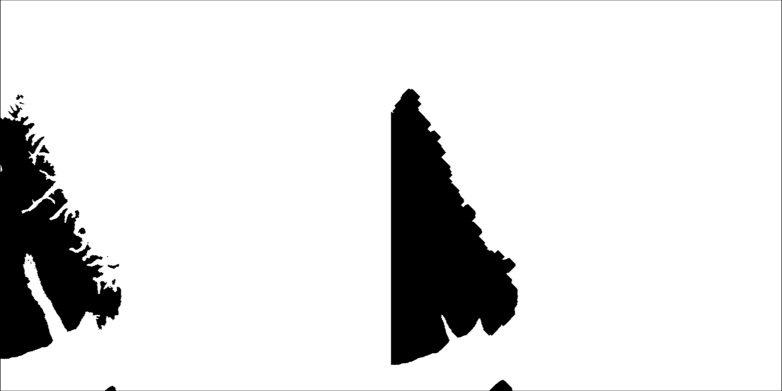

In [162]:
Images.mosaicview([Gray.(landmask_imgs.non_dilated), Gray.(landmask_imgs.dilated)], nrow=1)

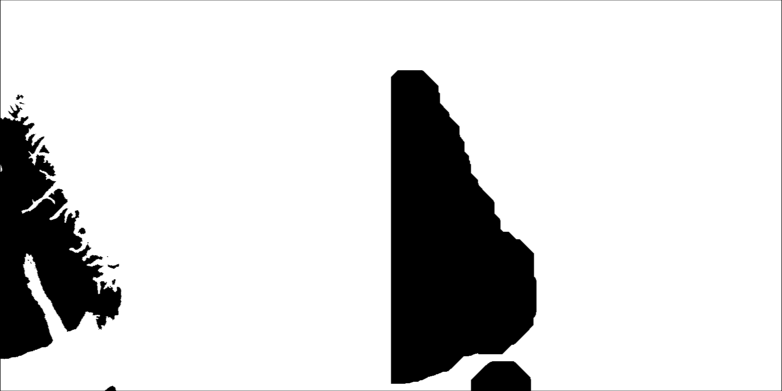

In [164]:
# Default landmask: flattened disk with radius ~25 pixels.
landmask_imgs = create_landmask(lm)
Images.mosaicview([Gray.(landmask_imgs.non_dilated), Gray.(landmask_imgs.dilated)], nrow=1)

## Generating the cloud mask
The cloud mask function aims to find the cloudy pixels that are unlikely to have visible ice underneath. This includes clouds over dark water surfaces and bright, opaque clouds. 

Let the intensity value of channel $i$ be given by $l_i$. The module creates a binary mask with the following steps:
1. Mask all pixels with $l_1 > 110 = T_C$.
2. Unmask pixels with $l_1 < 200 = T_1$ and $l_2 > 190 = T_2$.
3. Unmask pixels with $l_1/l_2 < 0.75 = R_{1,2}$.


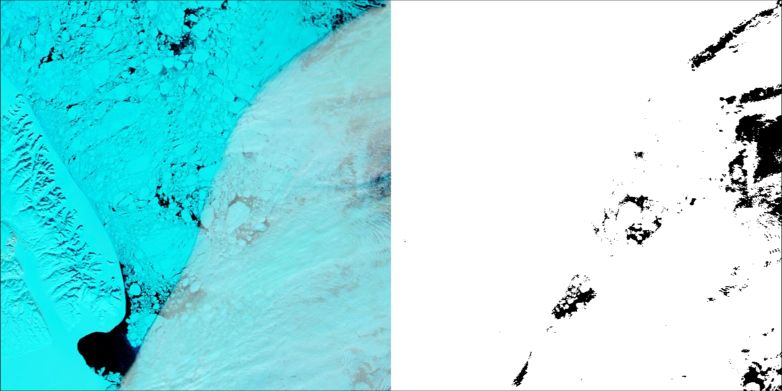

In [165]:
# set parameters for cloudmask
prelim_threshold = Float64(110 / 255)
band_7_threshold = Float64(200 / 255)
band_2_threshold = Float64(190 / 255)
ratio_lower = 0.0
ratio_upper = 0.75

# Create cloudmask from reflectance image
cloudmask = create_cloudmask(fc_image,
    prelim_threshold=prelim_threshold,
    band_7_threshold=band_7_threshold,
    band_2_threshold=band_2_threshold,
    ratio_lower=ratio_lower,
    ratio_upper=ratio_upper);

Images.mosaicview([fc_image, Gray.(cloudmask)], nrow=1) # cloud is black

These settings are the default in the Lopez-Acosta et al. 2019 paper; for other applications much stricter masking operations may be justified.

## Histogram equalization

TBD: Not clear which version should go here

In [169]:
?IceFloeTracker.adjust_histogram

!!! warning
    The following bindings may be internal; they may change or be removed in future versions:

      * `IceFloeTracker.adjust_histogram`


```
adjust_histogram([T::Type,] img, f::AbstractHistogramAdjustmentAlgorithm, args...; kwargs...)
```

Adjust histogram of `img` using algorithm `f`.

# Output

The return image `img_adjusted` is an `Array{T}`.

If `T` is not specified, then it's inferred.

# Examples

Just simply pass the input image and algorithm to `adjust_histogram`

```julia
img_adjusted = adjust_histogram(img, f)
```

This reads as "`adjust_histogram` of image `img` using algorithm `f`".

You can also explicitly specify the return type:

```julia
img_adjusted_float32 = adjust_histogram(Gray{Float32}, img, f)
```

See also [`adjust_histogram!`](@ref) for in-place histogram adjustment.


## Image sharpening

TBD: Not clear which version should go here

In [136]:

sharpened_truecolor_image = IceFloeTracker.imsharpen(tc_image, landmask_imgs.non_dilated)
sharpened_gray_truecolor_image = IceFloeTracker.imsharpen_gray(sharpened_truecolor_image, landmask_imgs.dilated);

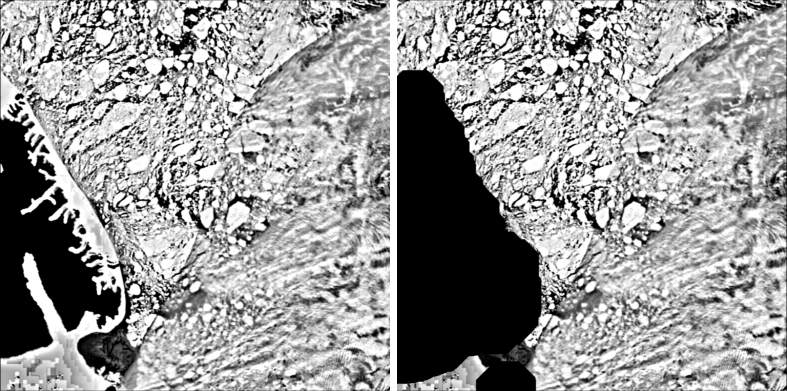

In [145]:
Images.mosaicview([Gray.(sharpened_truecolor_image),
                   Gray.(sharpened_gray_truecolor_image)], nrow=1, npad=10, fillvalue=255)

In [166]:
?imsharpen

search: imsharpen isopen reshape ischardev ismarked



```
imsharpen(truecolor_image, landmask_no_dilate, lambda, kappa, niters, nbins, rblocks, cblocks, clip, smoothing_param, intensity)
```

Sharpen `truecolor_image`.

# Arguments

  * `truecolor_image`: input image in truecolor
  * `landmask_no_dilate`: landmask for region of interest
  * `lambda`: speed of diffusion (0–0.25)
  * `kappa`: conduction coefficient for diffusion (25–100)
  * `niters`: number of iterations of diffusion
  * `nbins`: number of bins during histogram equalization
  * `rblocks`: number of row blocks to divide input image during equalization
  * `cblocks`: number of column blocks to divide input image during equalization
  * `clip`: Thresholds for clipping histogram bins (0–1); values closer to one minimize contrast enhancement, values closer to zero maximize contrast enhancement
  * `smoothing_param`: pixel radius for gaussian blurring (1–10)
  * `intensity`: amount of sharpening to perform
